# TP1 - Regresión e Introducción a la evaluación de modelos

## Dataset: Bike Sharing

El objetivo de este trabajo es predecir la cantidad de bicicletas alquiladas a partir de variables relacionadas con el clima, el calendario y el momento del día.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

## Carga e inspección del dataset
Usamos el archivo hour.csv del dataset de Bike Sharing

In [4]:
data = pd.read_csv("../data/hour.csv")
data.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 1. Limpieza de datos

In [6]:
print("Cantidad de filas:", data.shape[0])
print("Cantidad de columnas:", data.shape[1])

print("\nColumnas:")
print(data.columns.tolist())

print("\nTipos de datos:")
print(data.dtypes)

Cantidad de filas: 17379
Cantidad de columnas: 17

Columnas:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

Tipos de datos:
instant         int64
dteday            str
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


In [7]:
data.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


El dataset contiene variables relacionadas con fecha, hora, estación del año, clima, temperatura, humedad y cantidad de bicicletas alquiladas.

La variable objetivo que se busca predecir es `cnt`, que representa la cantidad total de bicicletas alquiladas en cada registro horario.

## 1.1 Variables categóricas
## 1.1 Variables categóricas

Aunque varias variables del dataset están almacenadas como números, algunas representan categorías y no cantidades continuas.

En particular:
- `season`: estación del año.
- `yr`: año.
- `mnth`: mes.
- `hr`: hora del día.
- `holiday`: indica si el día es feriado.
- `weekday`: día de la semana.
- `workingday`: indica si es un día laboral.
- `weathersit`: situación climática.

Estas variables se tratarán como categóricas cuando corresponda, ya que sus valores numéricos representan etiquetas y no magnitudes.

In [8]:
categorical_cols = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

for col in categorical_cols:
    print(f"\n{col}:")
    print(data[col].value_counts().sort_index())


season:
season
1    4242
2    4409
3    4496
4    4232
Name: count, dtype: int64

yr:
yr
0    8645
1    8734
Name: count, dtype: int64

mnth:
mnth
1     1429
2     1341
3     1473
4     1437
5     1488
6     1440
7     1488
8     1475
9     1437
10    1451
11    1437
12    1483
Name: count, dtype: int64

hr:
hr
0     726
1     724
2     715
3     697
4     697
5     717
6     725
7     727
8     727
9     727
10    727
11    727
12    728
13    729
14    729
15    729
16    730
17    730
18    728
19    728
20    728
21    728
22    728
23    728
Name: count, dtype: int64

holiday:
holiday
0    16879
1      500
Name: count, dtype: int64

weekday:
weekday
0    2502
1    2479
2    2453
3    2475
4    2471
5    2487
6    2512
Name: count, dtype: int64

workingday:
workingday
0     5514
1    11865
Name: count, dtype: int64

weathersit:
weathersit
1    11413
2     4544
3     1419
4        3
Name: count, dtype: int64


Para poder utilizar estas variables en los modelos de regresión, se aplicará una codificación adecuada. En las variables categóricas sin orden natural se utilizará One-Hot Encoding, evitando imponer relaciones numéricas artificiales entre las categorías.

## 1.2 Valores faltantes

Se analiza si existen valores faltantes en alguna de las variables del dataset. En caso de encontrarlos, será necesario definir una estrategia de tratamiento antes de entrenar los modelos.

In [9]:
missing_values = data.isnull().sum()

print("Valores faltantes por columna:")
print(missing_values)

print("\nCantidad total de valores faltantes:")
print(missing_values.sum())

Valores faltantes por columna:
instant       0
dteday        0
season        0
yr            0
mnth          0
hr            0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

Cantidad total de valores faltantes:
0


El resultado anterior indica que no existen valores faltantes, no será necesario eliminar filas ni aplicar métodos de imputación.

En caso de utilizar una versión del dataset que contenga valores faltantes, se deberá definir una estrategia de tratamiento de acuerdo con la cantidad y el tipo de variable afectada.

## 1.3 Outliers

Se analiza la posible presencia de valores atípicos en las variables numéricas del dataset.

Para detectarlos se utilizará el criterio del rango intercuartílico (IQR). Se consideran potenciales outliers los valores menores que:

Q1 - 1.5 × IQR

o mayores que:

Q3 + 1.5 × IQR

donde IQR = Q3 - Q1.

La detección de un outlier no implica necesariamente su eliminación. En este dataset, valores altos o bajos de variables climáticas o de cantidad de bicicletas alquiladas pueden representar situaciones reales.

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


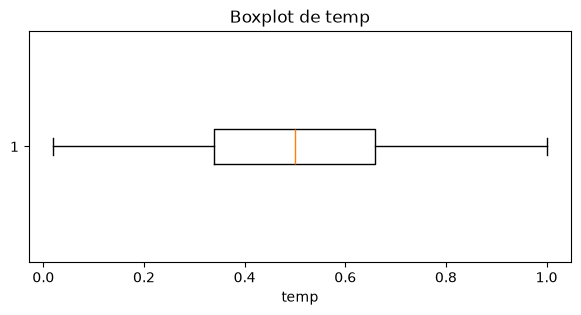

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


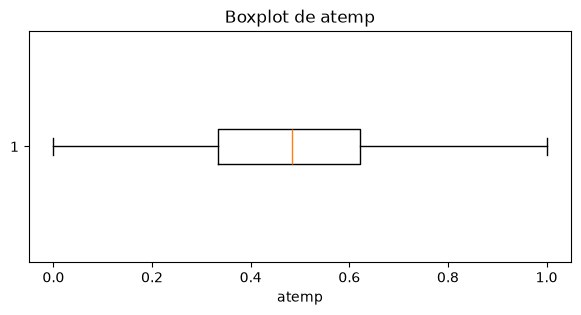

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


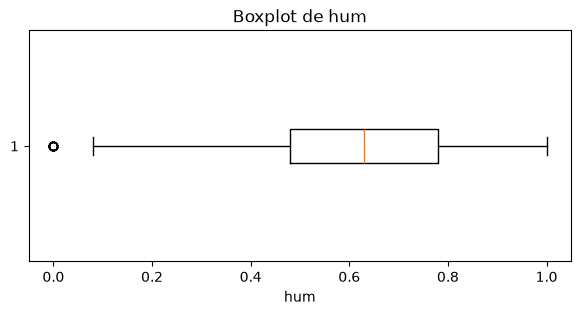

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


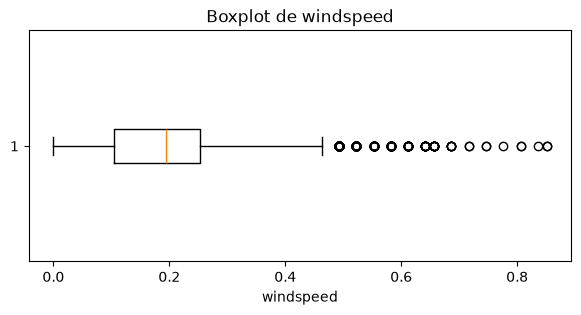

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


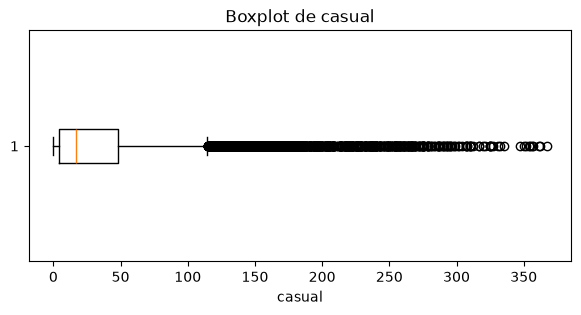

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


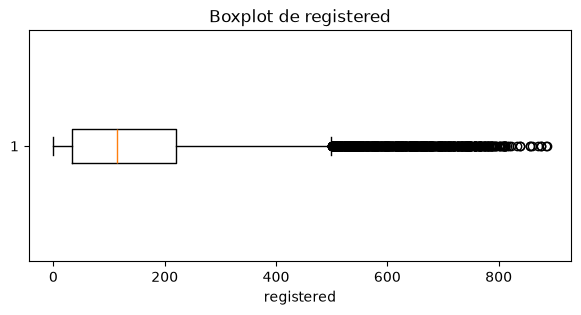

C:\Users\afrat\AppData\Local\Temp\ipykernel_17748\2918062782.py:49: MatplotlibDeprecationWarning: vert: bool was deprecated in Matplotlib 3.11 and will be removed in 3.13. Use orientation: {'vertical', 'horizontal'} instead.
  plt.boxplot(data[col], vert=False)


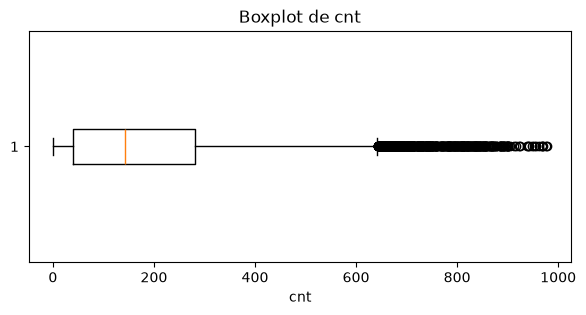

In [10]:
numeric_cols = [
    "temp",
    "atemp",
    "hum",
    "windspeed",
    "casual",
    "registered",
    "cnt"
]

outlier_summary = []

for col in numeric_cols:
    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    n_outliers = ((data[col] < lower_limit) | 
                  (data[col] > upper_limit)).sum()

    outlier_summary.append([
        col,
        Q1,
        Q3,
        lower_limit,
        upper_limit,
        n_outliers
    ])

outliers_df = pd.DataFrame(
    outlier_summary,
    columns=[
        "Variable",
        "Q1",
        "Q3",
        "Límite inferior",
        "Límite superior",
        "Cantidad de outliers"
    ]
)

outliers_df

for col in numeric_cols:
    plt.figure(figsize=(7, 3))
    plt.boxplot(data[col], vert=False)
    plt.title(f"Boxplot de {col}")
    plt.xlabel(col)
    plt.show()

Para facilitar la interpretación de los gráficos, se aclara el significado de las variables utilizadas: `temp` representa la temperatura, `atemp` la temperatura aparente o sensación térmica, `hum` la humedad, `windspeed` la velocidad del viento, `casual` la cantidad de usuarios ocasionales, `registered` la cantidad de usuarios registrados y `cnt` la cantidad total de bicicletas alquiladas.

### Decisión sobre los outliers

Los valores detectados mediante el criterio IQR se consideran inicialmente como posibles valores atípicos, pero no se eliminarán automáticamente.

En el contexto del Bike Sharing Dataset, una cantidad de alquileres especialmente alta, una determinada condición de humedad o valores extremos de viento pueden corresponder a observaciones reales.

Por este motivo, se decidió mantener los datos y evitar eliminar observaciones únicamente por superar los límites establecidos mediante IQR. Esta decisión podrá revisarse posteriormente si se observa que determinados valores afectan significativamente el desempeño de los modelos.

## 1.4 Selección de características

Antes de entrenar los modelos, se debe decidir qué variables utilizar como características de entrada.

La variable objetivo será:

- `cnt`: cantidad total de bicicletas alquiladas.

Se excluirán las siguientes variables:

- `instant`: corresponde únicamente a un identificador de cada registro y no aporta información útil para la predicción.
- `dteday`: representa la fecha. La información temporal relevante ya se encuentra representada mediante variables como año, mes, hora y día de la semana.
- `casual`: cantidad de usuarios casuales.
- `registered`: cantidad de usuarios registrados.

Las variables `casual` y `registered` no se utilizarán porque la variable objetivo `cnt` se obtiene directamente como la suma de ambas. Utilizarlas produciría fuga de información (data leakage), ya que estaríamos utilizando información que determina directamente el valor que queremos predecir.

Se conservarán como variables predictoras las características relacionadas con el calendario, el momento del día y las condiciones climáticas.

In [11]:
features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit",
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

target = "cnt"

X = data[features]
y = data[target]

print("Variables de entrada:")
print(X.columns.tolist())

print("\nVariable objetivo:")
print(target)

print("\nDimensiones de X:")
print(X.shape)

print("\nDimensiones de y:")
print(y.shape)

Variables de entrada:
['season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed']

Variable objetivo:
cnt

Dimensiones de X:
(17379, 12)

Dimensiones de y:
(17379,)


### Escalado de variables

Las variables numéricas continuas presentan diferentes escalas y unidades. Por este motivo, se aplicará estandarización mediante `StandardScaler`.

El escalado se realizará dentro del pipeline de procesamiento y se ajustará únicamente utilizando los datos de entrenamiento. De esta manera se evita que información del conjunto de test influya sobre el entrenamiento del modelo.

Las variables categóricas se transformarán mediante One-Hot Encoding.

In [12]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

categorical_features = [
    "season",
    "yr",
    "mnth",
    "hr",
    "holiday",
    "weekday",
    "workingday",
    "weathersit"
]

numerical_features = [
    "temp",
    "atemp",
    "hum",
    "windspeed"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features
        )
    ]
)

preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``

### Conclusión Ejercicio 1

Luego del análisis inicial:

- se identificaron las variables categóricas;
- se analizó la presencia de valores faltantes;
- se evaluaron posibles outliers mediante el criterio IQR;
- se decidió mantener inicialmente los valores atípicos detectados;
- se eliminaron variables que no aportan información útil o que producirían data leakage;
- se definieron las variables categóricas que serán codificadas mediante One-Hot Encoding;
- se definieron las variables numéricas que serán estandarizadas mediante StandardScaler.

Con los datos preparados, el siguiente paso será separar el dataset en conjuntos de entrenamiento y test y comenzar el entrenamiento de los modelos de regresión.

# 2. Regresión lineal

## 2.1 Separación de datos

Se separa el dataset en un conjunto de entrenamiento y un conjunto de test.

Se utilizará un 80% de los datos para entrenamiento y un 20% para test. El conjunto de test se reserva para la evaluación final y no se utiliza durante la selección ni el entrenamiento de los modelos.

La separación se realiza utilizando `random_state=42` para que el resultado sea reproducible.

In [13]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Cantidad de datos de entrenamiento:", X_train.shape[0])
print("Cantidad de datos de test:", X_test.shape[0])

Cantidad de datos de entrenamiento: 13903
Cantidad de datos de test: 3476


El conjunto de test queda reservado y no se utilizará durante la validación cruzada. Esto permite evaluar posteriormente el modelo utilizando datos que no participaron en su entrenamiento ni en su selección.

## 2.2 Validación cruzada

Para evaluar el modelo se utiliza k-fold cross-validation únicamente sobre el conjunto de entrenamiento.

Se utilizarán 5 folds. Esto significa que el conjunto de entrenamiento se divide en 5 partes. En cada iteración, 4 partes se utilizan para entrenar el modelo y la restante para validarlo.

El proceso se repite 5 veces, cambiando en cada iteración el fold utilizado para validación.

In [14]:
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error

In [15]:
linear_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("regressor", LinearRegression())
    ]
)

## 2.3 Entrenamiento del modelo

Para cada fold de la validación cruzada se entrena un modelo de regresión lineal utilizando los datos de entrenamiento correspondientes. Luego se calculan las predicciones sobre train y validación, y se evalúa el error mediante RMSE.

In [16]:
kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

train_rmse = []
val_rmse = []

for fold, (train_index, val_index) in enumerate(kf.split(X_train), start=1):

    X_fold_train = X_train.iloc[train_index]
    X_fold_val = X_train.iloc[val_index]

    y_fold_train = y_train.iloc[train_index]
    y_fold_val = y_train.iloc[val_index]

    linear_model.fit(X_fold_train, y_fold_train)

    y_train_pred = linear_model.predict(X_fold_train)
    y_val_pred = linear_model.predict(X_fold_val)

    rmse_train = np.sqrt(mean_squared_error(y_fold_train, y_train_pred))
    rmse_val = np.sqrt(mean_squared_error(y_fold_val, y_val_pred))

    train_rmse.append(rmse_train)
    val_rmse.append(rmse_val)

    print(f"Fold {fold}")
    print(f"RMSE Train: {rmse_train:.2f}")
    print(f"RMSE Validación: {rmse_val:.2f}")
    print()

print("RMSE promedio de Train:", round(np.mean(train_rmse), 2))
print("RMSE promedio de Validación:", round(np.mean(val_rmse), 2))

Fold 1
RMSE Train: 102.80
RMSE Validación: 98.48

Fold 2
RMSE Train: 101.97
RMSE Validación: 102.07

Fold 3
RMSE Train: 101.38
RMSE Validación: 104.50

Fold 4
RMSE Train: 101.18
RMSE Validación: 104.98

Fold 5
RMSE Train: 101.98
RMSE Validación: 101.93

RMSE promedio de Train: 101.86
RMSE promedio de Validación: 102.39


### Resultado de la regresión lineal

El modelo de regresión lineal obtuvo un RMSE promedio de aproximadamente 101.86 en entrenamiento y 102.39 en validación.

Como ambos valores son similares, no se observa una diferencia importante entre el desempeño sobre los datos de entrenamiento y los datos de validación. Esto sugiere que el modelo presenta un comportamiento relativamente estable y no muestra señales claras de sobreajuste.

Este resultado se utilizará como referencia para comparar posteriormente con los modelos de regresión polinómica.

# 3. Regresión polinómica

## 3.1 Transformación polinómica

Para capturar posibles relaciones no lineales entre las variables climáticas y la variable objetivo, se aplicará una transformación polinómica **únicamente sobre las variables numéricas continuas** (`temp`, `atemp`, `hum`, `windspeed`).

Las variables categóricas no se incluyen en la transformación polinómica: al estar codificadas mediante One-Hot Encoding, son variables binarias (0/1), y elevar una variable binaria a una potencia no genera información nueva (0² = 0, 1² = 1). Incluirlas solo aumentaría artificialmente la dimensionalidad sin aportar poder predictivo.

Se evaluarán los grados **2 y 3**:

- **Grado 2**: existe evidencia de que variables como `temp` tienen una relación no monótona con `cnt` (la cantidad de alquileres cae tanto en temperaturas muy bajas como muy altas), lo cual un modelo lineal no puede capturar pero un término cuadrático sí.
- **Grado 3**: se evalúa como alternativa más flexible, para verificar si agrega capacidad predictiva real o si comienza a sobreajustar.

No se evalúan grados superiores a 3: con 4 variables numéricas, el número de términos generados (incluyendo interacciones) crece rápidamente, aumentando el riesgo de sobreajuste y el costo computacional sin garantía de mejora.



In [17]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Lasso

degrees = [2, 3]

def build_poly_preprocessor(degree):
    numeric_poly_pipeline = Pipeline(
        steps=[
            ("poly", PolynomialFeatures(degree=degree, include_bias=False)),
            ("scaler", StandardScaler())
        ]
    )

    return ColumnTransformer(
        transformers=[
            ("num", numeric_poly_pipeline, numerical_features),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
        ]
    )

## 3.2 Entrenamiento del modelo

Se entrena un modelo de regresión lineal sobre las variables transformadas, para cada grado evaluado, utilizando el mismo esquema de k-fold cross-validation (5 folds) definido en la sección 2, sobre el mismo conjunto de entrenamiento.

In [18]:
poly_results = {}

for degree in degrees:

    poly_preprocessor = build_poly_preprocessor(degree)

    poly_model = Pipeline(
        steps=[
            ("preprocessor", poly_preprocessor),
            ("regressor", LinearRegression())
        ]
    )

    fold_train_rmse = []
    fold_val_rmse = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train), start=1):

        X_fold_train = X_train.iloc[train_index]
        X_fold_val = X_train.iloc[val_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_val = y_train.iloc[val_index]

        poly_model.fit(X_fold_train, y_fold_train)

        y_train_pred = poly_model.predict(X_fold_train)
        y_val_pred = poly_model.predict(X_fold_val)

        rmse_train = np.sqrt(mean_squared_error(y_fold_train, y_train_pred))
        rmse_val = np.sqrt(mean_squared_error(y_fold_val, y_val_pred))

        fold_train_rmse.append(rmse_train)
        fold_val_rmse.append(rmse_val)

    mean_train_rmse = np.mean(fold_train_rmse)
    mean_val_rmse = np.mean(fold_val_rmse)

    poly_results[degree] = {
        "train_rmse": mean_train_rmse,
        "val_rmse": mean_val_rmse
    }

    print(f"Grado {degree}")
    print(f"RMSE promedio Train: {mean_train_rmse:.2f}")
    print(f"RMSE promedio Validación: {mean_val_rmse:.2f}")
    print()

Grado 2
RMSE promedio Train: 100.64
RMSE promedio Validación: 101.26

Grado 3
RMSE promedio Train: 98.58
RMSE promedio Validación: 99.35



## 3.3 Regularización (opcional)

Se evalúa el efecto de la regularización L1 (Lasso) sobre el modelo polinómico. Para elegir sobre qué grado aplicarla, se selecciona automáticamente el grado con menor RMSE de validación obtenido en el punto 3.2, ya que no tiene sentido regularizar el modelo con peor desempeño de base.

Se evaluarán dos valores de `alpha` (equivalente a lambda): uno bajo, para aplicar una penalización suave, y uno más alto, para forzar una reducción más agresiva de coeficientes y observar si mejora la generalización (menor RMSE de validación) o si, por el contrario, el modelo pierde capacidad predictiva (underfitting).

In [19]:
best_degree = min(poly_results, key=lambda d: poly_results[d]["val_rmse"])
print(f"Grado seleccionado para regularización: {best_degree}")

alphas = [1.0, 10.0]
lasso_results = {}

best_preprocessor = build_poly_preprocessor(best_degree)

for alpha in alphas:

    lasso_model = Pipeline(
        steps=[
            ("preprocessor", best_preprocessor),
            ("regressor", Lasso(alpha=alpha, max_iter=5000))
        ]
    )

    fold_train_rmse = []
    fold_val_rmse = []

    for fold, (train_index, val_index) in enumerate(kf.split(X_train), start=1):

        X_fold_train = X_train.iloc[train_index]
        X_fold_val = X_train.iloc[val_index]

        y_fold_train = y_train.iloc[train_index]
        y_fold_val = y_train.iloc[val_index]

        lasso_model.fit(X_fold_train, y_fold_train)

        y_train_pred = lasso_model.predict(X_fold_train)
        y_val_pred = lasso_model.predict(X_fold_val)

        rmse_train = np.sqrt(mean_squared_error(y_fold_train, y_train_pred))
        rmse_val = np.sqrt(mean_squared_error(y_fold_val, y_val_pred))

        fold_train_rmse.append(rmse_train)
        fold_val_rmse.append(rmse_val)

    mean_train_rmse = np.mean(fold_train_rmse)
    mean_val_rmse = np.mean(fold_val_rmse)

    lasso_results[alpha] = {
        "train_rmse": mean_train_rmse,
        "val_rmse": mean_val_rmse
    }

    print(f"Lasso (grado {best_degree}, alpha={alpha})")
    print(f"RMSE promedio Train: {mean_train_rmse:.2f}")
    print(f"RMSE promedio Validación: {mean_val_rmse:.2f}")
    print()

Grado seleccionado para regularización: 3
Lasso (grado 3, alpha=1.0)
RMSE promedio Train: 104.43
RMSE promedio Validación: 104.83

Lasso (grado 3, alpha=10.0)
RMSE promedio Train: 153.96
RMSE promedio Validación: 154.05



# 4. Evaluación

A continuación se resumen los RMSE de validación obtenidos para cada configuración evaluada, indicando el grado del polinomio y, cuando corresponde, el valor de lambda (alpha) utilizado.

In [20]:
summary_rows = [
    ["Regresión lineal (sin transformación)", "-", "-", np.mean(train_rmse), np.mean(val_rmse)]
]

for degree, res in poly_results.items():
    summary_rows.append([
        "Regresión polinómica",
        degree,
        "-",
        res["train_rmse"],
        res["val_rmse"]
    ])

for alpha, res in lasso_results.items():
    summary_rows.append([
        "Regresión polinómica + Lasso",
        best_degree,
        alpha,
        res["train_rmse"],
        res["val_rmse"]
    ])

summary_df = pd.DataFrame(
    summary_rows,
    columns=["Modelo", "Grado", "Lambda (alpha)", "RMSE Train", "RMSE Validación"]
)

summary_df

,Modelo,Grado,Lambda (alpha),RMSE Train,RMSE Validación
0,Regresión lineal (sin transformación),-,-,101.861142,102.393177
1,Regresión polinómica,2,-,100.642743,101.264145
2,Regresión polinómica,3,-,98.582319,99.347890
3,Regresión polinómica + Lasso,3,1.0,104.430927,104.827024
4,Regresión polinómica + Lasso,3,10.0,153.960329,154.045721


In [22]:
final_model = Pipeline(
    steps=[
        ("preprocessor", build_poly_preprocessor(best_degree)),
        ("regressor", LinearRegression())
    ]
)

final_model.fit(X_train, y_train)

y_test_pred = final_model.predict(X_test)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))

print(f"RMSE final sobre test: {rmse_test:.2f}")

RMSE final sobre test: 97.58


**Regresión lineal vs. polinómica:** el modelo polinómico de grado 3 obtuvo el menor RMSE de validación (99.35), mejorando tanto respecto al lineal (102.39) como al polinómico de grado 2 (101.26). Esto confirma que existe una relación no lineal entre las variables climáticas/calendario y la demanda que el modelo lineal no llega a capturar. La regularización L1 (Lasso), en cambio, empeoró el resultado en ambos valores de alpha probados (104.83 y 154.05): como el modelo de grado 3 sin regularizar ya generalizaba bien (gap train/validación de apenas ~0.77), no había overfitting real que corregir, y la penalización adicional solo le restó capacidad de ajuste al modelo.

### 1. ¿Qué modelo obtuvo menor error?

El modelo de **regresión polinómica de grado 3, sin regularización**, con un RMSE de validación de **99.35**, el más bajo entre todas las configuraciones evaluadas.

### 2. ¿Cuál elegirían para una aplicación real?

El mismo modelo: **polinómica de grado 3, sin regularizar**. Es la opción que mejor equilibra bias y varianza — el RMSE de train (98.58) y el de validación (99.35) son muy parecidos, lo que indica que la mejora respecto al modelo lineal viene de capturar un patrón real en los datos y no de memorizar el conjunto de entrenamiento. Los modelos con Lasso quedan descartados porque empeoran el error sin aportar ninguna ventaja de generalización en este caso.

### 3. ¿Qué RMSE esperan que tenga en producción?

Para responder esto de forma honesta, evaluamos el modelo elegido **una única vez** sobre el conjunto de test (reservado desde el principio y nunca usado para tomar decisiones de modelado): se reentrenó con todo `X_train` y se calculó el RMSE sobre `X_test`.

**RMSE final sobre test: 97.58**

Este valor es consistente con la estimación que había dado el k-fold (99.35), lo cual es una buena señal: la validación cruzada fue un estimador confiable del desempeño real del modelo en datos nunca vistos. Como referencia, `cnt` tiene una media de ~189 bicis/hora y un máximo de 977, así que un error típico de ~98 bicis/hora es razonable pero no despreciable — indica que el modelo capturó buena parte del patrón (mejor que el lineal, con RMSE ~102), aunque probablemente todavía queden relaciones más complejas (interacciones entre clima y hora, eventos puntuales) sin explicar del todo.